In [1]:
%matplotlib notebook

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

<IPython.core.display.Javascript object>


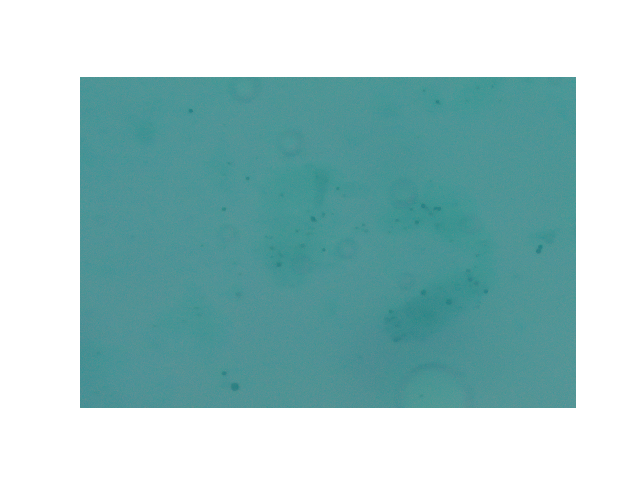

In [13]:
# img_dir = "/home/eholum/Documents/cell_counting/images/"
img_dir = "/home/eholum/Documents/cell_counting/Shed2019_perkinsus/"

img = cv2.cvtColor(cv2.imread(img_dir + "IMG_4656.JPG"), cv2.COLOR_BGR2Lab)

fig = plt.figure()
ax = fig.add_subplot(111)
ax.imshow(img)
ax.axis('off')
fig.show()


In [14]:
def check_overlap_rects(r1, r2):
    
    x1, y1, w1, h1 = r1
    x2, y2, w2, h2 = r2
      
    # If one rectangle is on left side of other 
    if(x1 + w1 < x2 or x2 + w2 < x1): 
        return False
  
    # If one rectangle is below other 
    if(y1 + h1 < y2 or y2 + h2 < y1): 
        return False
  
    return True

def check_unique(r, rects):
    
    for rect in rects:
        if check_overlap_rects(r, rect):
            return False
    
    return True

# True
print check_overlap_rects([0,0,5,5], [4,4,5,5])
print check_overlap_rects([4,4,5,5], [0,0,5,5])

# False
print check_overlap_rects([4,6,5,5], [0,0,5,5])
print check_overlap_rects([6,4,5,5], [0,0,5,5])

True
True
False
False


In [60]:
def find_contours(binary_img, color_img):

    contours, hier = cv2.findContours(binary_img, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)[-2:]
    contour_img = np.copy(color_img)
    cv2.drawContours(contour_img, contours, -1, (255,0,0), thickness=10)

    # Min area for rectangle
    min_wh = 18
    rects = []
    for contour in contours:
        (x,y,w,h) = cv2.boundingRect(contour)

        if w > min_wh and h > min_wh:
            r = [x, y, w, h]

            # Must be a unique rectangle
            if check_unique(r, rects):
                rects.append(r)

    rects = np.array(rects)

    rects_img = np.copy(color_img)
    for rect in rects:
        x, y, w, h = rect
        cv2.rectangle(rects_img, (x,y), (x+w, y+h), (255,255,0), 15)
        
    return rects, contour_img, rects_img



def filter_simple_threshold(img):
    gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    binary_img = cv2.adaptiveThreshold(gray_img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                       cv2.THRESH_BINARY_INV, 271, 12)

    # binary_img = cv2.threshold(gray_img, 40, 255, cv2.THRESH_BINARY_INV)[1]

    erosion_kernel=np.ones((3,3), dtype=np.uint8)
    dilation_kernel=np.ones((5,5), dtype=np.uint8)

    binary_img = cv2.erode(binary_img, erosion_kernel, iterations=1)
    binary_img = cv2.dilate(binary_img, dilation_kernel, iterations=3)
    
    return binary_img
    

In [66]:
root = "/home/eholum/Documents/cell_counting/"
img_dir = root + "Shed2019_perkinsus/"
out_dir = root + "output_images/"

output = open(root + "results.csv", "w")
output.write("filename, count_rgb, count_hsv\n")

img_names = sorted(os.listdir(img_dir))

def process_img(img_name):
    
    img = cv2.imread(img_dir + img_name)
    img_draw_on = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Do HSV img
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV_FULL)
    binary_img = filter_simple_threshold(img_hsv)
    rects, contour_img, rects_img_hsv = find_contours(binary_img, img_draw_on)
    hsv_ct = len(rects)

    # DO RGB img
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGBA)
    binary_img = filter_simple_threshold(img_rgb)
    rects, contour_img, rects_img_rgb = find_contours(binary_img, img_draw_on)
    rgb_ct = len(rects)

    # DO BGR img
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGBA)
    binary_img = filter_simple_threshold(img_rgb)
    rects, contour_img, rects_img_rgb = find_contours(binary_img, img_draw_on)
    rgb_ct = len(rects)
    
    return hsv_ct, rgb_ct, rects_img_hsv, rects_img_rgb



for img_name in img_names:
    hsv_ct, rgb_ct, rects_img_hsv, rects_img_rgb = process_img(img_name)
    output.write("%s,%s,%s\n" % (img_name, rgb_ct, hsv_ct))
    
    img_out_name = img_name.split(",")[0]
    
    cv2.imwrite("%s%s_RGB.JPG" %(out_dir, img_out_name), rects_img_rgb)
    cv2.imwrite("%s%s_HSV.JPG" %(out_dir, img_out_name), rects_img_hsv)
    
    print img_name, hsv_ct, rgb_ct
    

output.close()

fig = plt.figure()
ax = fig.add_subplot(111)
ax.imshow(rects_img_hsv)
ax.axis('off')
fig.show()

fig = plt.figure()
ax = fig.add_subplot(111)
ax.imshow(rects_img_rgb)
ax.axis('off')
fig.show()
    


IMG_3981.JPG 112 51
IMG_4020.JPG 130 99


KeyboardInterrupt: 